In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [3]:
# Importo las funciones de configuración
from src.config import reports_dir, load_config

Current working directory: /home/jorge/development/ImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [4]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [5]:
tensorboard_dir_metrics = reports_dir() /'tensorboard_metrics_csv'

In [6]:
modelo_baseline = 'convolutional_autoencoder_model_final_best_hyperparameters_2_2'
modelo_cheng2020 = 'compressai_cheng2020_anchor_2_2_BIS'

In [7]:
csv_baseline_psnr = tensorboard_dir_metrics / modelo_baseline / 'val_PSNR.csv'
csv_baseline_ssim = tensorboard_dir_metrics / modelo_baseline / 'val_SSIM.csv'
csv_baseline_ratio = tensorboard_dir_metrics / modelo_baseline / 'val_Compression_Ratio.csv'


In [8]:
csv_cheng2020_psnr = tensorboard_dir_metrics / modelo_cheng2020 / 'val_PSNR.csv'
csv_cheng2020_ssim = tensorboard_dir_metrics / modelo_cheng2020 / 'val_SSIM.csv'
csv_cheng2020_ratio = tensorboard_dir_metrics / modelo_cheng2020 / 'val_Compression_Ratio.csv'

In [9]:
df_baseline_psnr = pd.read_csv(csv_baseline_psnr)
df_baseline_ssim = pd.read_csv(csv_baseline_ssim)
df_baseline_ratio = pd.read_csv(csv_baseline_ratio)


In [11]:
df_cheng2020_psnr = pd.read_csv(csv_cheng2020_psnr)
df_cheng2020_ssim = pd.read_csv(csv_cheng2020_ssim)
df_cheng2020_ratio = pd.read_csv(csv_cheng2020_ratio)

## Graficamos

### PSNR

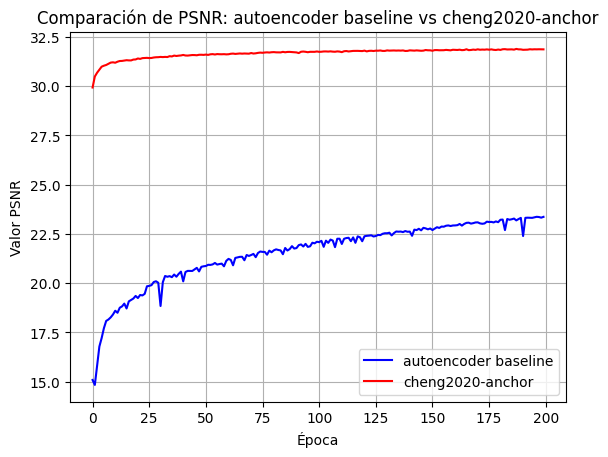

In [13]:
# Crear la gráfica
plt.plot(df_baseline_psnr['Step'], df_baseline_psnr['Value'], label='autoencoder baseline', color='b')
plt.plot(df_cheng2020_psnr['Step'], df_cheng2020_psnr['Value'], label='cheng2020-anchor', color='r')

# Añadir etiquetas y título en español
plt.xlabel('Época')
plt.ylabel('Valor PSNR')
plt.title('Comparación de PSNR: autoencoder baseline vs cheng2020-anchor')

# Añadir leyenda para diferenciar las curvas
plt.legend()

# Añadir rejilla
plt.grid(True)

# Mostrar la gráfica
plt.show()

## SSIM

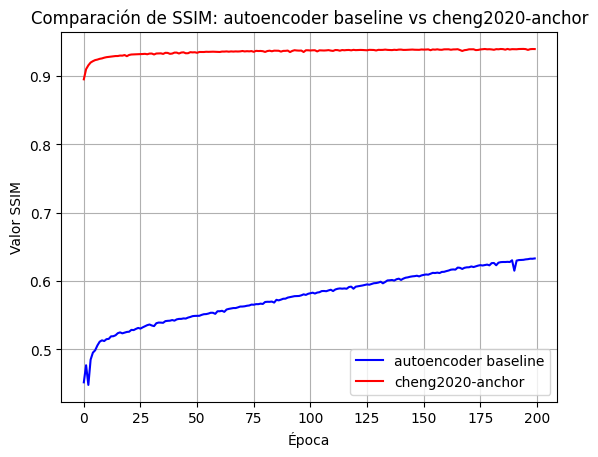

In [14]:
# Crear la gráfica
plt.plot(df_baseline_ssim['Step'], df_baseline_ssim['Value'], label='autoencoder baseline', color='b')
plt.plot(df_cheng2020_ssim['Step'], df_cheng2020_ssim['Value'], label='cheng2020-anchor', color='r')

# Añadir etiquetas y título en español
plt.xlabel('Época')
plt.ylabel('Valor SSIM')
plt.title('Comparación de SSIM: autoencoder baseline vs cheng2020-anchor')

# Añadir leyenda para diferenciar las curvas
plt.legend()

# Añadir rejilla
plt.grid(True)

# Mostrar la gráfica
plt.show()

## Razón de Compresión

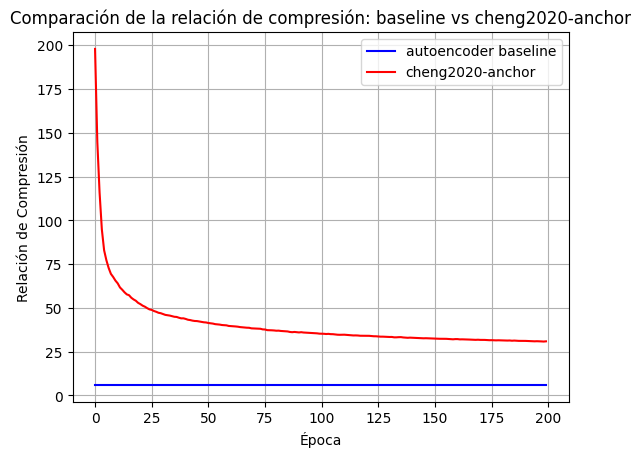

In [17]:
# Crear la gráfica
plt.plot(df_baseline_ratio['Step'], df_baseline_ratio['Value'], label='autoencoder baseline', color='b')
plt.plot(df_cheng2020_ratio['Step'], df_cheng2020_ratio['Value'], label='cheng2020-anchor', color='r')

# Añadir etiquetas y título en español
plt.xlabel('Época')
plt.ylabel('Relación de Compresión')
plt.title('Comparación de la relación de compresión: baseline vs cheng2020-anchor')

# Añadir leyenda para diferenciar las curvas
plt.legend()

# Añadir rejilla
plt.grid(True)

# Mostrar la gráfica
plt.show()